<a href="https://colab.research.google.com/github/AnirudhPhophalia/Dog-vs-wolf/blob/main/dog_vs_wolf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download teh required dependencies

In [2]:
!pip install kagglehub --quiet
# Import necessary libraries
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split
# shutil is used for high-level file operations
import shutil

Download the dataset

In [4]:
path = kagglehub.dataset_download("harishvutukuri/dogs-vs-wolves")
print("Dataset path:", path) # dataset path and contents folowed
print("Contents:", os.listdir(path))

100%|██████████| 222M/222M [00:01<00:00, 163MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/harishvutukuri/dogs-vs-wolves/versions/2
Contents: ['data']


In [5]:
data_dir = os.path.join(path, 'data')
print("Data dir contents:", os.listdir(data_dir)) # to knoe what the data directory contains

Data dir contents: ['wolves', 'dogs']


In [6]:
split_base_dir = '/kaggle/working/split_data'
train_dir = os.path.join(split_base_dir, 'train')
val_dir = os.path.join(split_base_dir, 'validation')

In [7]:
# create train and validation directories for both dogs and wolves
for label in ['dogs', 'wolves']:
    os.makedirs(os.path.join(train_dir, label), exist_ok=True)
    os.makedirs(os.path.join(val_dir, label), exist_ok=True)

In [8]:
# Split the data and copy images to the training and validation directories
for label in ['dogs', 'wolves']:
    src_dir = os.path.join(data_dir, label)
    images = os.listdir(src_dir)
    # splitting of images
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(train_dir, label, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(val_dir, label, img))

In [9]:
# Print the contents of the training abd validation directiory
print("Train dir contents:", os.listdir(train_dir))
print("Validation dir contents:", os.listdir(val_dir))

total_train_images = sum(len(os.listdir(os.path.join(train_dir, label))) for label in ['dogs', 'wolves'])
total_val_images = sum(len(os.listdir(os.path.join(val_dir, label))) for label in ['dogs', 'wolves'])

print('Total training images:', total_train_images)
print('Total validation images:', total_val_images)

Train dir contents: ['wolves', 'dogs']
Validation dir contents: ['wolves', 'dogs']
Total training images: 1600
Total validation images: 400


So we can see that there are 1600 training images and 400 testing images, as we haev done split of 20 percent

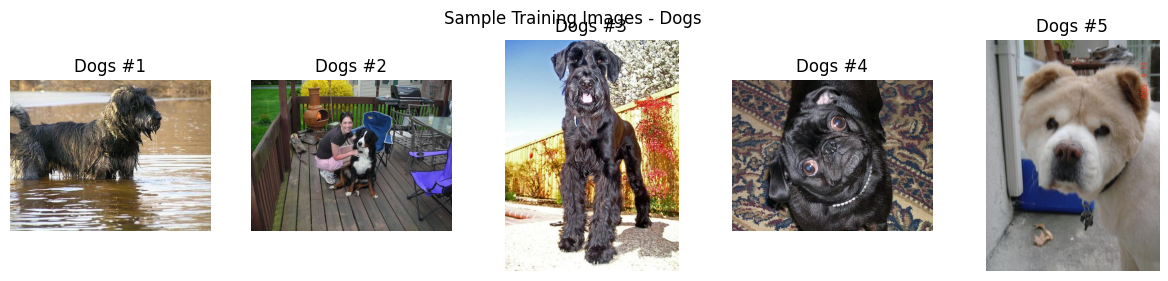

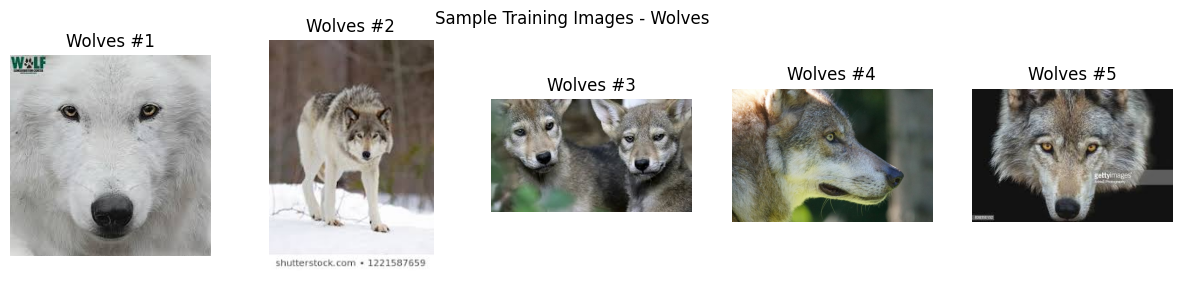

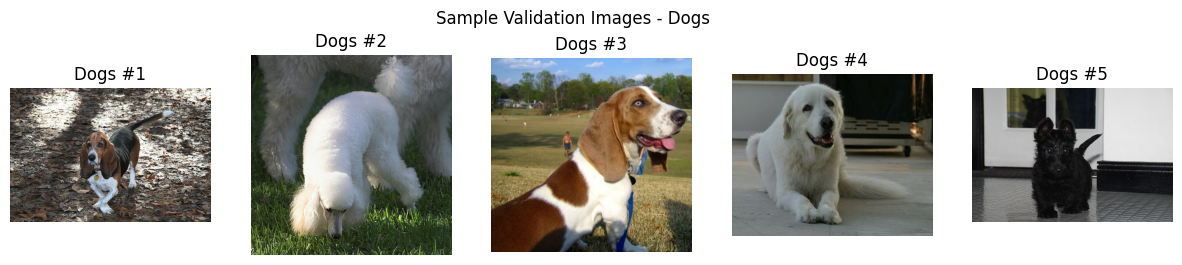

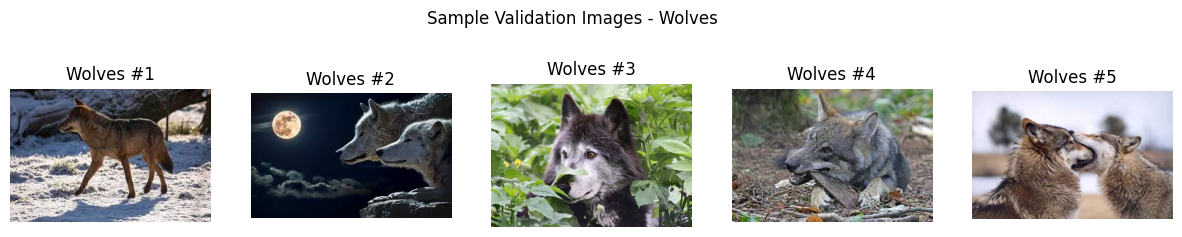

In [10]:
from PIL import Image
import random

# it display sthe images
def display_images_from_class(base_dir, class_name, num_images=5, title="Images"):
    class_dir = os.path.join(base_dir, class_name)
    images = os.listdir(class_dir)

    # Randomly select a few images
    selected_images = random.sample(images, min(num_images, len(images)))

    plt.figure(figsize=(15, 3))
    for idx, img_name in enumerate(selected_images):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)

        plt.subplot(1, num_images, idx + 1)
        plt.imshow(img)
        plt.title(f"{class_name.capitalize()} #{idx+1}")
        plt.axis('off')

    plt.suptitle(title)
    plt.show()

# Show sample training images from each class
display_images_from_class(train_dir, 'dogs', num_images=5, title="Sample Training Images - Dogs")
display_images_from_class(train_dir, 'wolves', num_images=5, title="Sample Training Images - Wolves")

# Show sample validation images from each class
display_images_from_class(val_dir, 'dogs', num_images=5, title="Sample Validation Images - Dogs")
display_images_from_class(val_dir, 'wolves', num_images=5, title="Sample Validation Images - Wolves")


I am doing data augmentation before only as at the end we have to do it to improve accuracy so i am doing it before

In [11]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,    # normalization
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)


Lets preprocess our data

In [12]:
# lets first create a generator for training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'      # Use binary class mode for binary classification
)

# now agenerator for validation data
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


In [13]:
#now lets build a model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [16]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.5139 - loss: 1.1509 - val_accuracy: 0.6068 - val_loss: 0.6507
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6431 - loss: 0.6444 - val_accuracy: 0.7318 - val_loss: 0.5670
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.6716 - loss: 0.6016 - val_accuracy: 0.7057 - val_loss: 0.6180
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.6954 - loss: 0.5781 - val_accuracy: 0.7292 - val_loss: 0.5622
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.7391 - loss: 0.5576 - val_accuracy: 0.7083 - val_loss: 0.5635
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.7486 - loss: 0.5315 - val_accuracy: 0.7630 - val_loss: 0.5502
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.7445 - loss: 0.5379 - val_accuracy: 0.6354 - val_loss: 0.6258
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.7459 - loss: 0.5264 - val_accuracy: 0.8021 - v

In [18]:
loss, acc = model.evaluate(val_generator)
print(f"\nTest Accuracy: {acc:.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 440ms/step - accuracy: 0.7987 - loss: 0.4061

Test Accuracy: 0.81


We got a accuracy of 81%.

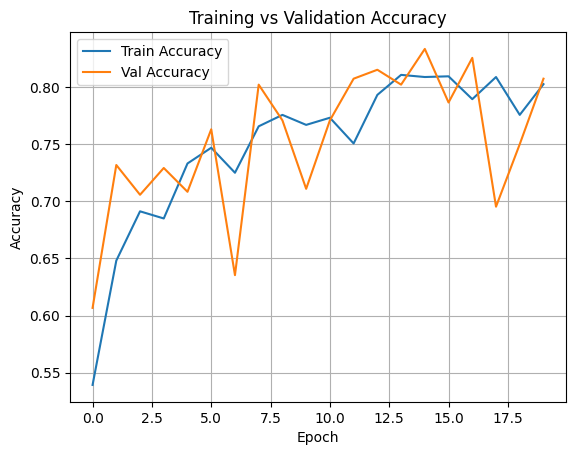

In [17]:
# Plot the training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
# Set the title of the plot
plt.title('Training vs Validation Accuracy')
# Set the x-axis label
plt.xlabel('Epoch')
# Set the y-axis label
plt.ylabel('Accuracy')
# Add a legend to the plot
plt.legend()
# Add a grid to the plot
plt.grid(True)
# Display the plot
plt.show()